In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pyshtools as pysh
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.feature_selection import VarianceThreshold
import os 
from meshplot import plot, subplot 
import anndata as ad
import pandas as pd

import igl 
from scipy.sparse.linalg import eigsh
from tqdm import tqdm

In [6]:
from src import utils 

import importlib
import src.fatemarkers
import src.meshharm

importlib.reload(src.meshharm)
importlib.reload(src.fatemarkers)
from src.fatemarkers import FateMarkers

In [3]:
path = 'Data/20251001/'

timepoints = ['day1p5', 'day2', 'day2p5', 'day3', 'day3p5', 'day4', 'day4p5', 'day4p5-more']

zarr_names = {
        'day1p5': 'r0.zarr',
        'day2':'r0.zarr',
        'day2p5':'r0.zarr',
        'day3':'r0.zarr',
        'day3p5':'r0.zarr',
        'day4':'r0.zarr',
        'day4p5':'r0.zarr',
        'day4p5-more':'r0.zarr',
}


wells = {
    'day1p5': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06'],
    'day2': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06'],
    'day2p5': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06'],
    'day3': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'B02', 'B03'],
    'day3p5': ['A01', 'A02', 'A03', 'A04', 'B03'],
    'day4': ['A02', 'A03', 'A04', 'A05', 'A06', 'B01', 'B02'],
    'day4p5': ['A06', 'B06'],
    'day4p5-more': ['C01', 'C02', 'C03', 'C04', 'C05', 'C06'],
}

rounds = {
    'day1p5': ['0_fused_zillum_registered'],
    'day2': ['0_fused_zillum_registered'],
    'day2p5': ['0_fused_zillum_registered'],
    'day3': ['0_fused_zillum_registered'],
    'day3p5': ['0_fused_zillum_registered'],
    'day4': ['0_fused_zillum_registered'],
    'day4p5': ['0_fused_zillum_registered'],
    'day4p5-more': ['0_fused_zillum_registered'],
}



times_dic = {
    '1p5': 1.5,
    '2': 2,
    '2p5': 2.5,
    '3': 3,
    '3p5': 3.5,
    '4': 4,
    '4p5': 4.5,
    '4p5-more': 4.5
}

In [7]:
annotation_names = {
    'lgr': '0.C02.percentile99_class',
    'chroma': '0.C03.percentile99_class',
    'cycd': '0.C04.percentile99_class',
    'muc': '1.C03.percentile99_class',
    'aldob': '1.C04.percentile99_class',
    'gluc': '2.C02.percentile99_class',
    'cyca': '2.C03.percentile99_class',
    'agr': '2.C04.percentile99_class',
    'sero': '3.C02.percentile99_class',
    'lyz': '3.C03.percentile99_class',
}

# state an order 
correct_order = list(annotation_names.keys())

def complexity(m, threshold=0.015): 
    for l in range(1, m.lmax+1): 
        err = m.compute_recon_quality(lmax=l)
        if err < threshold:
            return l
    return m.lmax

def load(mesh_path, save_path): 
    m = FateMarkers()
    m.load_mesh_from_file(mesh_path)
    m.load_results(save_path)

    _, _, _, _, deci_indices = igl.decimate(m.v, m.f, 200) 
    frac_diff = m.compute_recon_quality()
    indices = [m.field_names.index(annotation_names[name]) for name in correct_order] 
    c = complexity(m, threshold=0.015)
    return frac_diff, m.fields[deci_indices][:, indices], c 

In [35]:
times = [] 
fracs = [] 
ids = [] 
complexities = []
fms = [] 


for timepoint in timepoints:
    zarr_name = zarr_names[timepoint]
    for well_name in wells[timepoint]:
        round_name = rounds[timepoint][0]

        file_path = f"{path}{timepoint}/{zarr_name}/{well_name[0]}/{well_name[1:]}/{round_name}/"
        labels = np.load(f"{file_path}/fm_data/good_labels.npy")
        for label in tqdm(labels):
            save_path = f"{file_path}/fm_data/{label}"
            mesh_path = f"{file_path}/meshes/nnorg_linked_multi_annotated_class/{label}.vtp"
            if os.path.exists(save_path + '_coeffs.npz'):
                frac, fm, c = load(mesh_path, save_path)
                fms.append(fm)
                times.append(timepoint[3:])
                fracs.append(frac)
                ids.append(f"{timepoint}_{well_name}_{label}") 
                complexities.append(c)

100%|██████████| 60/60 [00:10<00:00,  5.80it/s]


In [36]:
threshold = np.percentile(fracs, 95)
recon_mask = np.array(fracs) < threshold

# Convert boolean mask to indices array
recon_indices = np.where(recon_mask)[0]

# Convert to numpy arrays for set operations
ids_array = np.array(ids)
filtered_ids_array = np.array(ids_array[recon_mask])

# filter using this mask 
filtered_complexities = np.array(complexities)[recon_mask]
filtered_fms = [fms[i] for i in recon_indices]
filtered_times = np.array(times)[recon_mask]
filtered_ids = np.array(ids)[recon_mask]

In [37]:
# draw evenly from complexities
complexity_intervals = [(2, 3), (4, 4), (5, 6)]
no_per_group = [np.sum((filtered_complexities >= interval[0]) & (filtered_complexities <= interval[1])) for interval in complexity_intervals] 
samples_per_group = int(np.min(no_per_group))

selected_indices = []
for interval in complexity_intervals:
    group_indices = np.where((filtered_complexities >= interval[0]) & (filtered_complexities <= interval[1]))[0]
    selected_indices.extend(np.random.choice(group_indices, size=samples_per_group, replace=False)) 

filtered_times = filtered_times[selected_indices]
filtered_ids = filtered_ids[selected_indices]

In [38]:
# rescale hks by the sum over a single timepoint across one organoid 
def normalise(fm): 
    # Only compute upper quantile amongst non-zero values
    nonzero_mask = fm > 0
    upper_quantile = np.zeros((1, fm.shape[1]))
    for col in range(fm.shape[1]):
        nonzero_values = fm[nonzero_mask[:, col], col]
        if len(nonzero_values) > 0:
            upper_quantile[0, col] = np.percentile(nonzero_values, 75)
        else:
            upper_quantile[0, col] = 1  # avoid division by zero
    mean_rm = fm / upper_quantile
    return (mean_rm)

normalised_filtered_fms = [normalise(filtered_fms[i]) for i in selected_indices]

In [45]:
print(len(selected_indices))

552


In [48]:
# Apply indices to filter hkss list
collected_fms = np.concatenate(normalised_filtered_fms)

# Expand filtered_complexities to match collected_fms shape
expanded_complexities = np.concatenate([
    np.full(len(normalised_filtered_fms[i]), filtered_complexities[i]) 
    for i in range(len(normalised_filtered_fms))
])
print(collected_fms.shape, expanded_complexities.shape)

np.savez('sim/fm_raw_values.npz', 
         filtered_ids=filtered_ids,
         filtered_times=filtered_times,
         filtered_fms=collected_fms, 
         fms_per_organoid = [len(fm) for fm in normalised_filtered_fms]
)

(56292, 10) (56292,)


In [4]:
res = np.load('sim/fm_raw_values.npz', allow_pickle=True)
filtered_ids = res['filtered_ids']
filtered_times = res['filtered_times']
collected_fms = res['filtered_fms']
fms_per_organoid = res['fms_per_organoid']

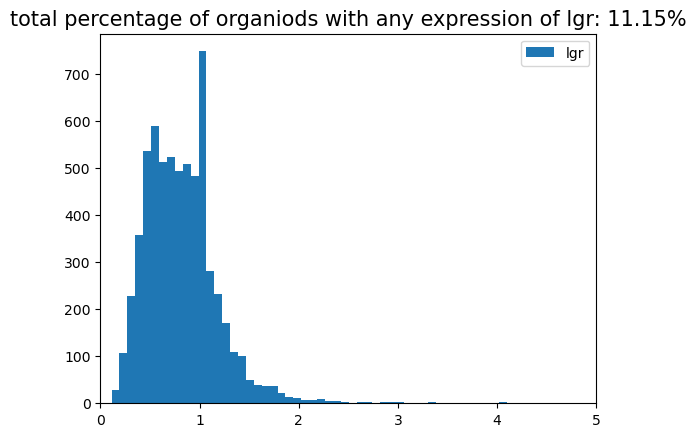

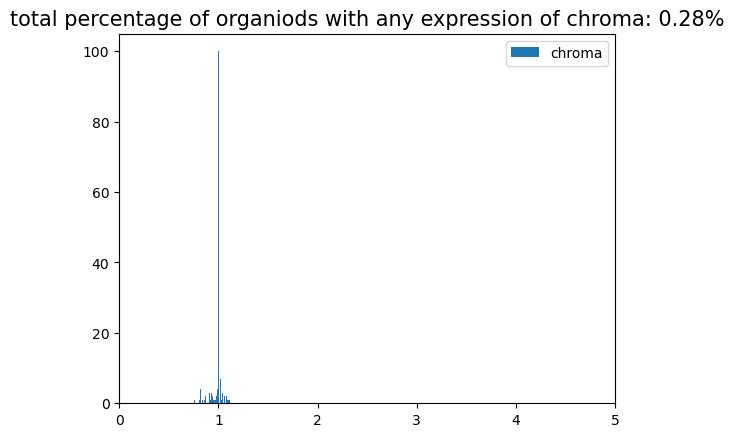

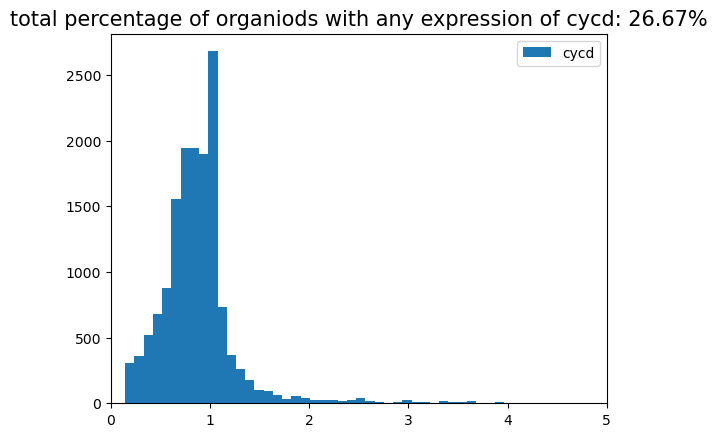

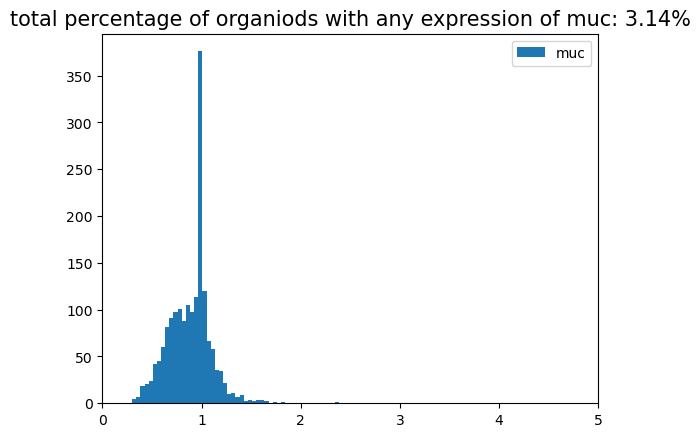

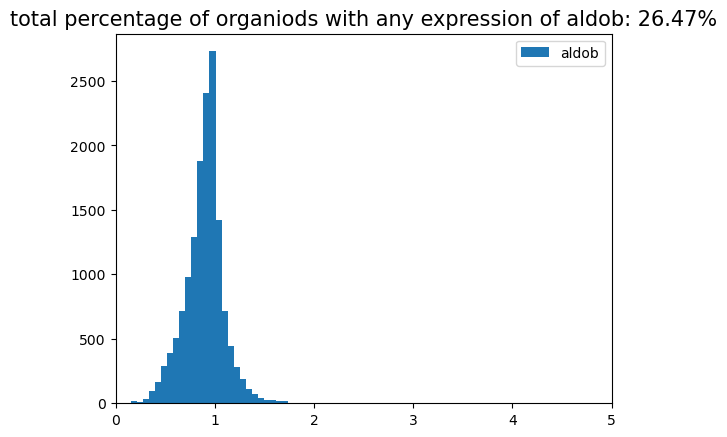

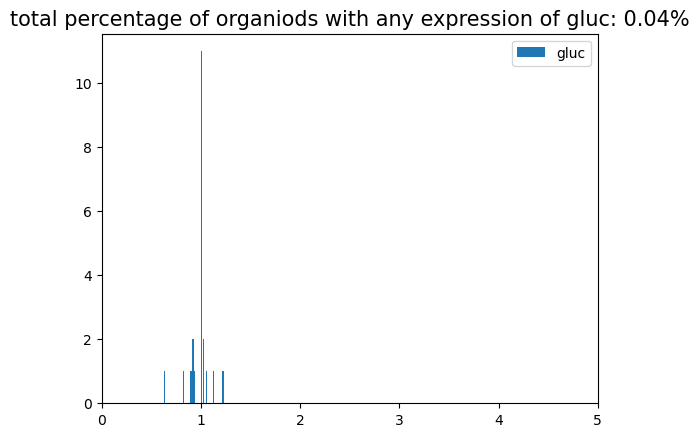

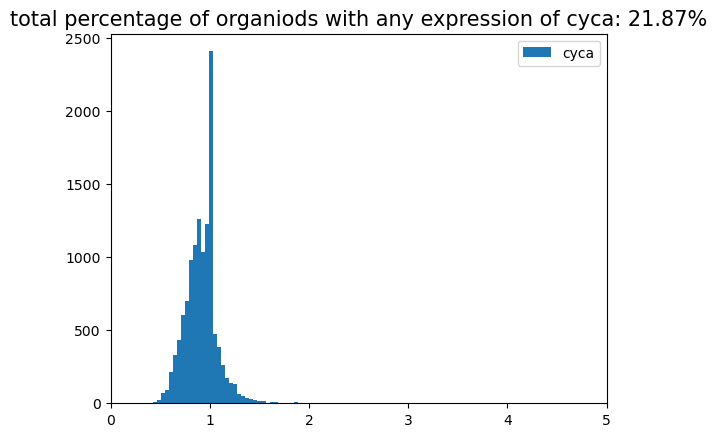

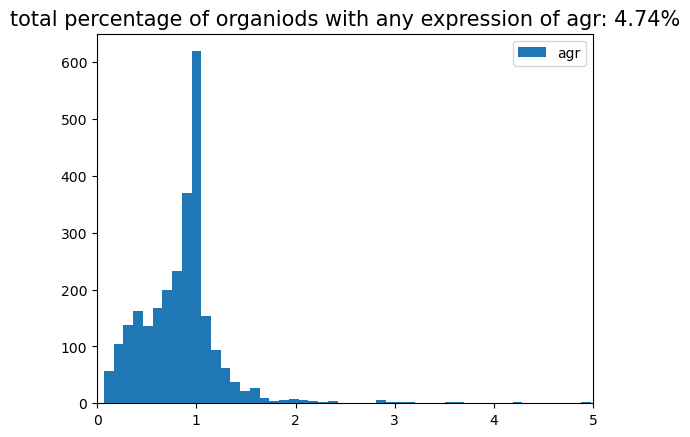

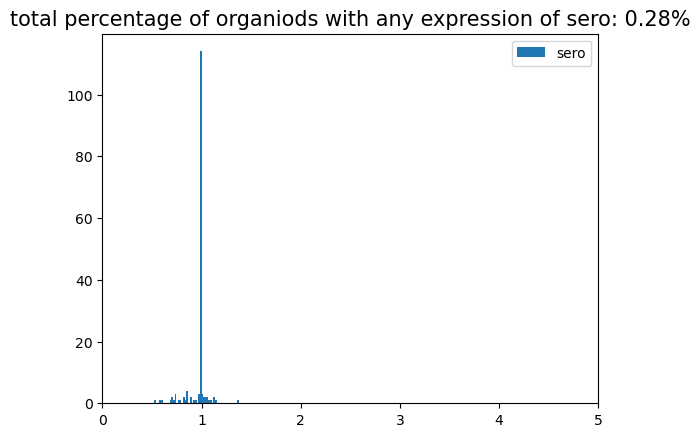

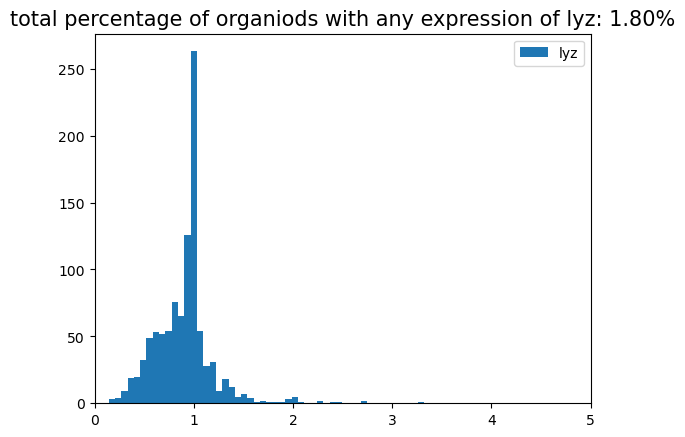

In [8]:
for i in range(10): 
    feature = collected_fms[:, i]
    plt.hist(feature[(feature > 0) & (feature < 5)], bins=50, label=correct_order[i])
    plt.xlim([0, 5])
    plt.legend()
    plt.title(f'total percentage of organiods with any expression of {correct_order[i]}: {np.sum(feature > 0) / len(feature) * 100:.2f}%', fontsize=15)
    plt.show() 

In [9]:
outlier_mask = np.any(collected_fms > 5, axis=1)
fm_names_of_choice = ['lgr', 'chroma', 'muc', 'aldob', 'agr', 'sero', 'lyz']
fm_indices_of_choice = [correct_order.index(name) for name in fm_names_of_choice]
filtered_rescaled_fms = collected_fms[~outlier_mask][:, fm_indices_of_choice]

In [12]:
data = np.load('sim/bof_raw_value.npz')
filtered_times = data['filtered_times']
filtered_ids = data['filtered_ids']
collected_hks = data['filtered_hks']

In [13]:
from sklearn.cluster import KMeans
cluster = KMeans(n_clusters=5, random_state=42)
cluster.fit(filtered_rescaled_fms)

dim_reducer = PCA(n_components=2)
rep2d = dim_reducer.fit_transform(filtered_rescaled_fms)

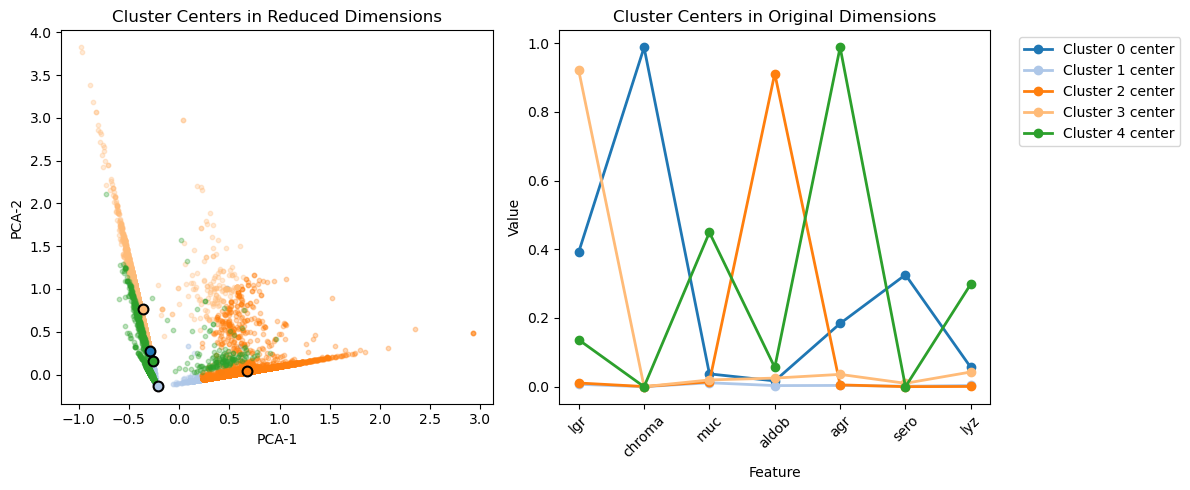

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left plot: Clusters in reduced dimensions
colors = plt.cm.tab20(np.arange(cluster.n_clusters))
for i in range(cluster.n_clusters):
    mask = cluster.labels_ == i
    ax1.scatter(rep2d[mask, 0], rep2d[mask, 1], c=[colors[i]], s=10, alpha=0.3)

# Transform cluster centers to 2D
cluster_centers_2d = dim_reducer.transform(cluster.cluster_centers_)

for i in range(cluster.n_clusters):
    ax1.scatter(cluster_centers_2d[i, 0], cluster_centers_2d[i, 1], 
                c=[colors[i]], s=50, marker='o', edgecolors='black', 
                linewidths=1.5, label=f'Cluster {i} center')

ax1.set_xlabel('PCA-1')
ax1.set_ylabel('PCA-2')
ax1.set_title('Cluster Centers in Reduced Dimensions')

# Right plot: Cluster centers in original dimension
for i in range(cluster.n_clusters):
    ax2.plot(cluster.cluster_centers_[i], '-o', color=colors[i], 
             label=f'Cluster {i} center', linewidth=2)

ax2.set_xticks(range(len(fm_names_of_choice)))
ax2.set_xticklabels(fm_names_of_choice, rotation=45)
ax2.set_xlabel('Feature')
ax2.set_ylabel('Value')
ax2.set_title('Cluster Centers in Original Dimensions')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Total unique combinations: 59

Top 5 most frequent combinations:


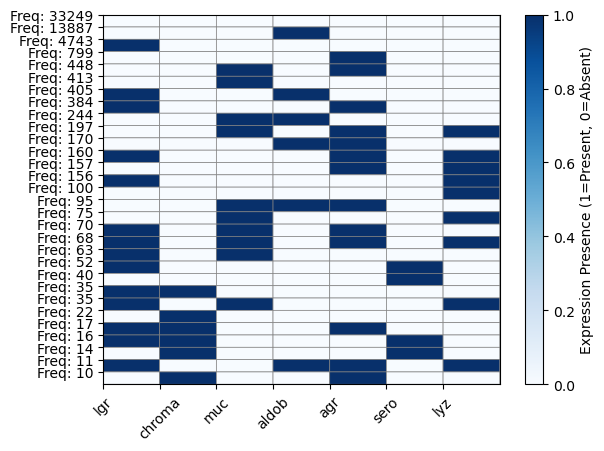

In [144]:
from collections import Counter

bool_fm = filtered_rescaled_fms > 0

# Convert boolean rows to tuples for hashing
row_tuples = [tuple(row) for row in bool_fm]

# Count frequencies
combination_counts = Counter(row_tuples)

# Sort by frequency (descending)
ranked_combinations = combination_counts.most_common()

# Display results
print(f"Total unique combinations: {len(ranked_combinations)}")
print("\nTop 5 most frequent combinations:")

n = 30 
combs, freqs = zip(*ranked_combinations[:n])

plt.pcolor(np.array(combs[:n]), cmap='Blues', edgecolors='grey', linewidths=0.5)
plt.gca().invert_yaxis()
plt.yticks(range(n), [f'Freq: {freqs[i]}' for i in range(n)])
plt.xticks(range(len(fm_names_of_choice)), fm_names_of_choice, rotation=45)
plt.colorbar(label='Expression Presence (1=Present, 0=Absent)')
plt.show()

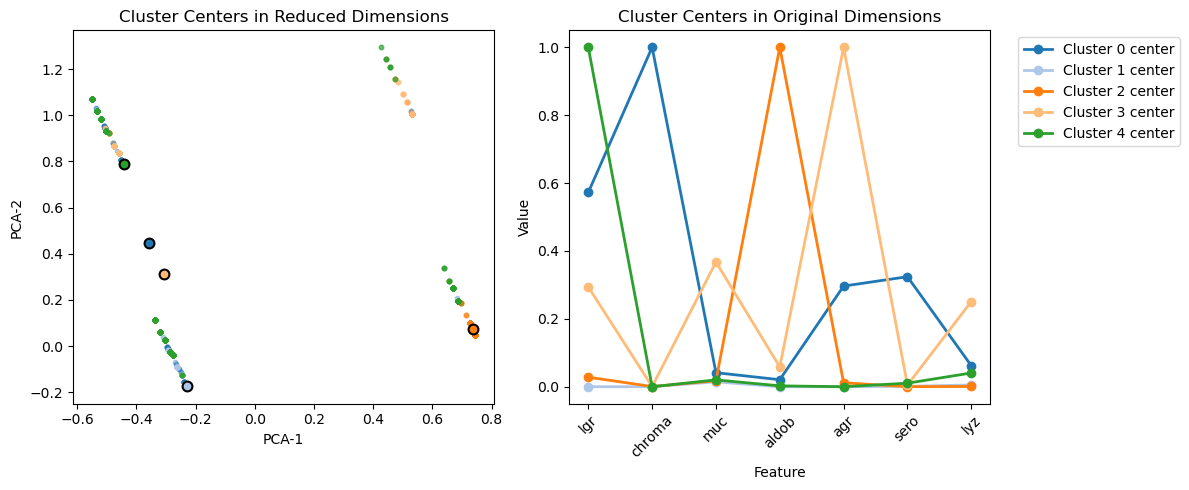

In [145]:

dim_reducer = PCA(n_components=2)
bool_2d = dim_reducer.fit_transform(bool_fm)
cluster_bool = KMeans(n_clusters=5, random_state=42)
cluster_bool.fit(bool_fm)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left plot: Clusters in reduced dimensions
colors = plt.cm.tab20(np.arange(cluster_bool.n_clusters))
for i in range(cluster.n_clusters):
    mask = cluster.labels_ == i
    ax1.scatter(bool_2d[mask, 0], bool_2d[mask, 1], c=[colors[i]], s=10, alpha=0.3)

# Transform cluster centers to 2D
cluster_centers_2d_bool = dim_reducer.transform(cluster_bool.cluster_centers_)
    
for i in range(cluster_bool.n_clusters):
    ax1.scatter(cluster_centers_2d_bool[i, 0], cluster_centers_2d_bool[i, 1], 
                c=[colors[i]], s=50, marker='o', edgecolors='black', 
                linewidths=1.5, label=f'Cluster {i} center')

ax1.set_xlabel('PCA-1')
ax1.set_ylabel('PCA-2')
ax1.set_title('Cluster Centers in Reduced Dimensions')

# Right plot: Cluster centers in original dimension
for i in range(cluster_bool.n_clusters):
    ax2.plot(cluster_bool.cluster_centers_[i], '-o', color=colors[i], 
             label=f'Cluster {i} center', linewidth=2)

ax2.set_xticks(range(len(fm_names_of_choice)))
ax2.set_xticklabels(fm_names_of_choice, rotation=45)
ax2.set_xlabel('Feature')
ax2.set_ylabel('Value')
ax2.set_title('Cluster Centers in Original Dimensions')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [20]:
cluster_id = cluster.labels_

# compute distance to the nearest cluster center 
dist = np.zeros(filtered_rescaled_fms.shape[0])
sigmas = [] 
for i in range(cluster.labels_.max() + 1):
    m = (cluster_id == i)
    center = cluster.cluster_centers_[i].reshape(1,-1)
    d = np.linalg.norm(filtered_rescaled_fms[m] - center, axis=1)
    dist[m] = d
    sigmas.append(np.std(d))

sigma = np.sqrt(np.mean(dist**2))
print("Sigma:", sigma)

vocab = np.array(cluster.cluster_centers_)
print(vocab.shape) 

Sigma: 0.27425386744536606
(5, 7)


In [36]:
encoding = filtered_rescaled_fms - vocab[cluster_id]

encoding = np.linalg.norm(filtered_rescaled_fms[:, np.newaxis, :] - vocab[np.newaxis, :, :], axis=2) 
encoding = np.exp(-encoding**2 / ( 2 * np.array(sigmas)[np.newaxis, :] **2))

# encoding = np.exp(-encoding**2 / ( 2 * sigma**2))

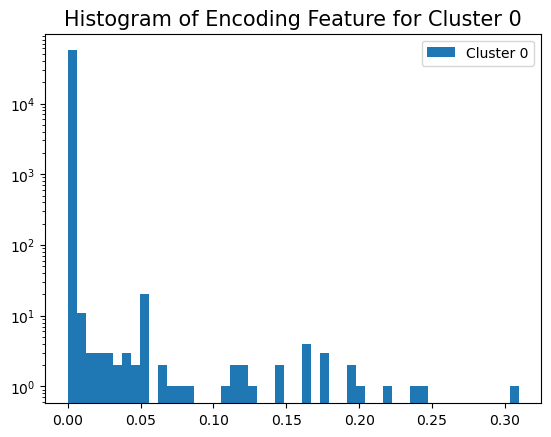

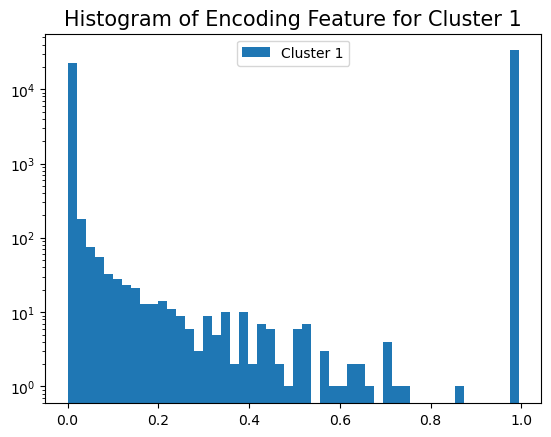

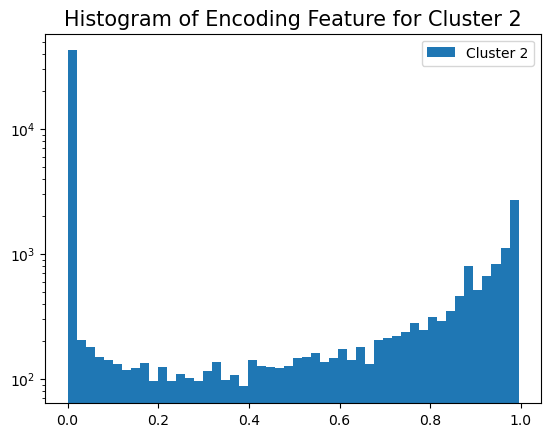

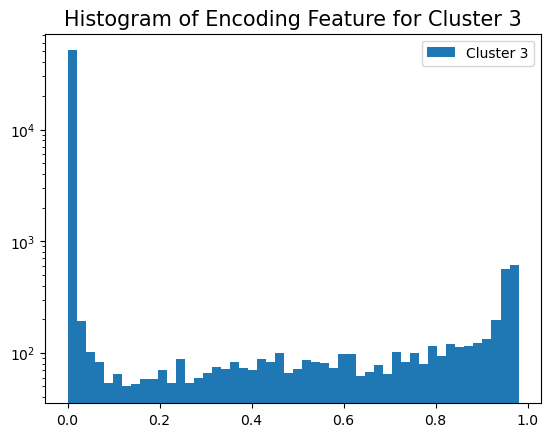

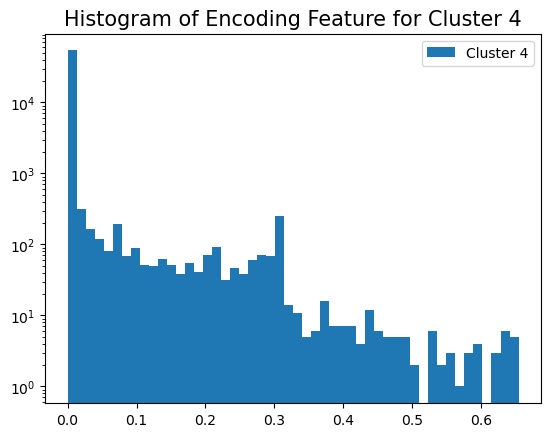

In [37]:
for i in range(encoding.shape[-1]): 
    feature = encoding[:, i]
    plt.hist(feature, bins=50, label=f'Cluster {i}')
    plt.yscale('log')
    plt.legend()
    plt.title(f'Histogram of Encoding Feature for Cluster {i}', fontsize=15)
    plt.show()

In [150]:
np.savez('sim/vocab_fm.npz', vocab=vocab, sigma=sigma, fm_names_of_choice=fm_names_of_choice)